# Marketing Funnel & Conversion Analysis  
## Data Overview

In this notebook, we take a first look at the Bank Marketing Campaign dataset.
The goal is to understand the structure of the data, the target variable, and
how this dataset fits into a marketing funnel analysis.

Each row represents a customer who was contacted during a marketing campaign.
The outcome of interest is whether the customer subscribed to a term deposit.

In [1]:
# Importing required libraries

# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Plot settings
plt.style.use("default")
sns.set_palette("muted")
sns.set_context("notebook", font_scale=1.2)

In [2]:
# Load the raw bank marketing dataset
df = pd.read_csv("bank-full.csv", sep=";")

# Preview the first few rows
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [3]:
# Checking the number of rows and columns
df.shape

(45211, 17)

In [4]:
# Inspect data types and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


Understanding the size and structure of the dataset helps confirm:
- How much customer data is available for analysis
- Whether columns are numerical or categorical
- If any columns already contain missing values

This step prevents incorrect assumptions later in the analysis.

In [5]:
# List of all column names
pd.DataFrame(df.columns)

,0
0,age
1,job
2,marital
3,education
4,default
5,balance
6,housing
7,loan
8,contact
9,day


In [6]:
# Summary statistics for numerical features
df.describe()

,age,balance,day,duration,campaign,pdays,previous
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323
std,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


In [7]:
# Summary for categorical features
df.describe(include="object")

,job,marital,education,default,housing,loan,contact,month,poutcome,y
count,45211,45211,45211,45211,45211,45211,45211,45211,45211,45211
unique,12,3,4,2,2,2,3,12,4,2
top,blue-collar,married,secondary,no,yes,no,cellular,may,unknown,no
freq,9732,27214,23202,44396,25130,37967,29285,13766,36959,39922


The target variable in this dataset is `y`.

- `yes` → customer subscribed to a term deposit (conversion)
- `no`  → customer did not subscribe (funnel drop-off)

This makes the dataset well suited for marketing funnel
and conversion performance analysis.

### Target Distribution

In [8]:
# Count of conversions vs non-conversions
pd.DataFrame(df["y"].value_counts())

,count
y,
no,39922
yes,5289


In [9]:
# Percentage distribution
pd.DataFrame(df["y"].value_counts(normalize=True) * 100)

,proportion
y,
no,88.30152
yes,11.69848


### Target Visualization

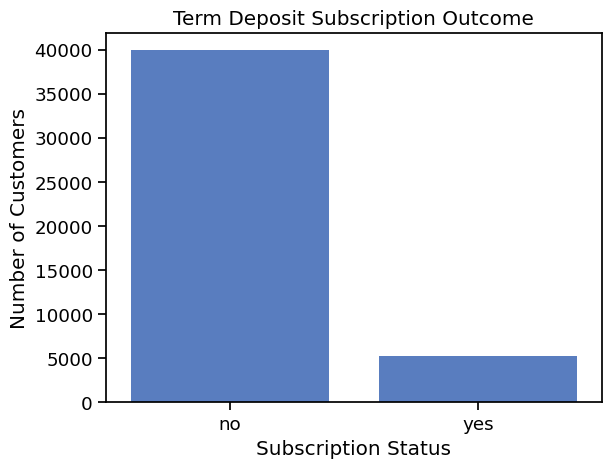

In [10]:
# Visualizing the imbalance in the target variable

sns.countplot(data=df, x="y")
plt.title("Term Deposit Subscription Outcome")
plt.xlabel("Subscription Status")
plt.ylabel("Number of Customers")
plt.show()

### Initial Observations

- A large majority of customers did not subscribe to the term deposit.
- This imbalance is expected in real-world marketing campaigns.
- The data reflects a realistic funnel where many contacts lead to few conversions.

This confirms that the dataset is appropriate for analyzing
conversion drop-offs and optimization opportunities.